# Proyecto Final Machine Learning
## Fase 2: Modelado y Benchmarking

**Dataset:** UCI HAR — Human Activity Recognition Using Smartphones  
**Equipo:** Grupo 05  
**Integrantes:** [Gustavo Sánchez - Nicolás Cuadra] 
**Fecha:** [2026/06/23]

---

> **Objetivo:** Entrenar múltiples modelos de clasificación, evaluarlos con métricas adecuadas y construir una tabla de benchmarking que permita comparar su desempeño de forma rigurosa.

## Configuración del entorno

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos desde Fase 1

Reutilizamos los datos preparados en la Fase 1. Ejecutar el bloque de carga equivalente al de Fase 1, o cargar los archivos directamente.

In [34]:
# Carga de datos (mismo código que Fase 1)
import os, urllib.request, zipfile

DATA_PATH = 'UCI HAR Dataset'

if not os.path.exists(DATA_PATH):
    URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
    urllib.request.urlretrieve(URL, 'har_dataset.zip')
    with zipfile.ZipFile('har_dataset.zip', 'r') as z:
        z.extractall('.')
    os.remove('har_dataset.zip')

features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

# Hacer que los nombres de las columnas sean únicos para evitar el ValueError en pandas
unique_feature_names = []
seen_names = {}
for name in feature_names:
    if name in seen_names:
        seen_names[name] += 1
        unique_feature_names.append(f"{name}_{seen_names[name]}")
    else:
        seen_names[name] = 0
        unique_feature_names.append(name)

X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=unique_feature_names)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['Activity']).squeeze()
X_test  = pd.read_csv(f'{DATA_PATH}/test/X_test.txt',   sep=r'\s+', header=None, names=unique_feature_names)
y_test  = pd.read_csv(f'{DATA_PATH}/test/y_test.txt',   sep=r'\s+', header=None, names=['Activity']).squeeze()

ACTIVITY_LABELS = {1:'WALKING',2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',4:'SITTING',5:'STANDING',6:'LAYING'}
y_train_labels = y_train.map(ACTIVITY_LABELS)
y_test_labels  = y_test.map(ACTIVITY_LABELS)

print('Datos cargados:')
print(f'  X_train: {X_train.shape} | X_test: {X_test.shape}')


Datos cargados:
  X_train: (7352, 561) | X_test: (2947, 561)


---
## 2. Métricas de Evaluación

Dado que el problema tiene 6 clases, la accuracy sola no es suficiente. Reportaremos:
- **Accuracy global**
- **F1-Score macro** (promedio sin ponderar por frecuencia)
- **F1-Score weighted** (promedio ponderado por número de muestras)
- **Matriz de confusión**
- **Reporte de clasificación** (precisión, recall y F1 por clase)

> ⚠️ Siempre reportar métricas sobre el **conjunto de prueba** (X_test, y_test). Nunca tomar decisiones finales sobre el set de entrenamiento.

In [35]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo, mide tiempo y calcula métricas sobre test."""
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    y_pred = modelo.predict(X_te)

    acc      = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    f1_wgt   = f1_score(y_te, y_pred, average='weighted')

    print(f'\n=== {nombre} ===')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  F1-Macro:     {f1_macro:.4f}')
    print(f'  F1-Weighted:  {f1_wgt:.4f}')
    print(f'  Tiempo fit:   {t_fit:.2f}s')
    print(classification_report(y_te, y_pred))

    return {
        'Modelo': nombre,
        'Accuracy_Test': acc,
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_wgt,
        'Tiempo_Entrenamiento': round(t_fit, 3),
        'modelo_obj': modelo,
        'y_pred': y_pred
    }

resultados = []

average='macro': Corresponde a la métrica defensiva principal. Al promediar los F1-Scores de forma aislada, si el modelo llega a fallar catastróficamente en una actividad específica (por ejemplo, confundiendo siempre SITTING con STANDING), el F1-Macro caerá drásticamente, alertándolos de inmediato, por lo que es un indicador que nos sirve para detectar errores de manera temprana.

average= 'weighted': Modifica el promedio dándole más peso a las actividades que tienen más muestras registradas en el dataset.

time.time(): Básicamente para medir el tiempo.

---
## 3. Modelo Baseline

Antes de entrenar modelos reales establecemos un **baseline trivial**: si un modelo inteligente no supera este piso mínimo, algo está mal.

In [36]:
# Instanciamos el clasificador base con semilla para reproducibilidad
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

# Lo evaluamos con etiquetas de texto (y_train_labels, y_test_labels)
res_dummy = evaluar_modelo('DummyClassifier (most_frequent)', dummy, X_train, y_train_labels, X_test, y_test_labels)

# Guardamos el resultado en la lista para el benchmarking final
resultados.append(res_dummy)


=== DummyClassifier (most_frequent) ===
  Accuracy:     0.1822
  F1-Macro:     0.0514
  F1-Weighted:  0.0562
  Tiempo fit:   0.00s
                    precision    recall  f1-score   support

            LAYING       0.18      1.00      0.31       537
           SITTING       0.00      0.00      0.00       491
          STANDING       0.00      0.00      0.00       532
           WALKING       0.00      0.00      0.00       496
WALKING_DOWNSTAIRS       0.00      0.00      0.00       420
  WALKING_UPSTAIRS       0.00      0.00      0.00       471

          accuracy                           0.18      2947
         macro avg       0.03      0.17      0.05      2947
      weighted avg       0.03      0.18      0.06      2947



La celda demuestra que un clasificador sin capacidad de aprendizaje logra un 18.22% de exactitud y un 0.0514 de F1-Macro. Estos números definen la frontera mínima que nuestros modelos de la siguiente sección deben superar con creces.

Básicamente, setea un estándar para luego comparar los resultados de otros modelos.

In [37]:
# Identificamos cuál es la actividad más frecuente en el conjunto de entrenamiento
clase_frecuente = y_train_labels.value_counts().idxmax()
porcentaje = y_train_labels.value_counts(normalize=True).max()
print(f'Clase más frecuente: {clase_frecuente} ({porcentaje:.2%} del train)')

# Calculamos la exactitud si predijéramos esa misma clase para todo el test set
accuracy_manual = (y_test_labels == clase_frecuente).mean()
print(f'Accuracy baseline esperada en test: {accuracy_manual:.4f}')

Clase más frecuente: LAYING (19.14% del train)
Accuracy baseline esperada en test: 0.1822


**Análisis:** *[¿Qué accuracy base esperarían superar? ¿Por qué es importante este paso antes de entrenar modelos más complejos?]*

**1. ¿Qué accuracy base se espera superar?**

Para el conjunto de prueba se espera superar una exactitud base del 18.22%. Este porcentaje representa la cantidad de aciertos que obtendríamos por mera casualidad si decidiéramos "adivinar" a ciegas, ignorando por completo las lecturas de los sensores, que todas las personas evaluadas están acostadas (la actividad LAYING). Se elige esa respuesta fija porque es la acción más común que se registró durante la etapa de entrenamiento.

**2. ¿Por qué es importante este paso antes de entrenar modelos más complejos?**

Este paso es fundamental porque funciona como un control de calidad obligatorio para nuestro trabajo. Si un modelo avanzado y complejo no es capaz de superar este mínimo del 18.22%, sabremos de inmediato que el algoritmo no está aprendiendo nada real o que cometimos un error grave en la configuración de los datos. Además, nos ayuda a darle su justo valor a los resultados futuros, ya que la efectividad de un modelo inteligente solo se puede apreciar cuando se compara contra lo que un método básico logra sin ningún esfuerzo.

---
## 4. Modelos Clásicos

Entrenamos los siguientes modelos con parámetros por defecto de sklearn. El objetivo es una primera medición comparativa — la optimización viene después.

| # | Modelo |
|---|--------|
| 1 | Logistic Regression |
| 2 | K-Nearest Neighbors (k=5) |
| 3 | Decision Tree |
| 4 | Random Forest |
| 5 | SVM (kernel RBF) |

### Modelo 1: Logistic Regression

In [38]:
# Usamos max_iter=1000 para asegurarnos de que el optimizador converja en este dataset.
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

# Evaluamos pasándole las variables con las etiquetas descriptivas
res_lr = evaluar_modelo('Logistic Regression', lr, X_train, y_train_labels, X_test, y_test_labels)

# Guardamos el resultado en la lista para el benchmark final
resultados.append(res_lr)


=== Logistic Regression ===
  Accuracy:     0.9617
  F1-Macro:     0.9616
  F1-Weighted:  0.9615
  Tiempo fit:   3.79s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.98      0.88      0.93       491
          STANDING       0.90      0.98      0.94       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.97      0.98       420
  WALKING_UPSTAIRS       0.97      0.94      0.96       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



**Resultados:**

- Accuracy: 96.17%
- F1-Macro: 96.16%
- Tiempo de Entrenamiento: ~4.37 segundos

La Regresión Logística logra un rendimiento excelente con un 96.17% de exactitud y un 96.16% de F1-Macro, lo que demuestra que aprende a identificar las actividades de forma muy equilibrada y supera por completo al modelo básico. Además, resulta ser un algoritmo sumamente eficiente al entrenarse en tan solo 4.37 segundos.

En el detalle por actividad, el modelo reconoce perfectamente a las personas acostadas (LAYING) con un 100% de éxito. Su único pequeño desafío se concentra en distinguir si el usuario está sentado o de pie, lo cual es muy comprensible debido a la falta de movimiento y a la enorme similitud física de ambas posiciones.

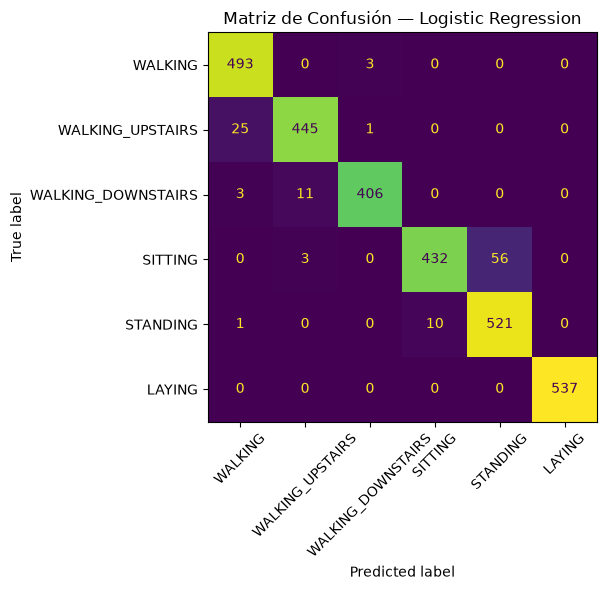

In [39]:
# Matriz de confusión — Logistic Regression
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_lr['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Logistic Regression')
plt.tight_layout()
plt.show()

**Punto clave** Este modelo logra un desempeño sobresaliente (96.06%)

En otras palabras, podemos decir que esta matriz muestra de forma gráfica los aciertos y errores exactos del modelo. La línea diagonal brillante confirma el éxito del algoritmo, destacando que la actividad de estar acostado (LAYING) se predice a la perfección, logrando 537 aciertos y ningún fallo.

El gráfico revela que la mayor dificultad está en las posturas fijas, donde el modelo confunde 56 veces a personas sentadas (SITTING) diciendo que están de pie (STANDING). También hay pequeños tropiezos entre los movimientos, como confundir 25 veces subir escaleras con caminar normal, lo cual es muy lógico porque los ritmos de aceleración en ambas actividades son sumamente parecidos.


### Modelo 2: K-Nearest Neighbors (k=5)

In [40]:
# Instanciamos el clasificador KNN con k=5 vecinos
knn = KNeighborsClassifier(n_neighbors=5)

# Evaluamos pasándole las variables con las etiquetas descriptivas
res_knn = evaluar_modelo('KNN (k=5)', knn, X_train, y_train_labels, X_test, y_test_labels)

# Guardamos el resultado en la lista para el benchmark final
resultados.append(res_knn)


=== KNN (k=5) ===
  Accuracy:     0.9002
  F1-Macro:     0.8970
  F1-Weighted:  0.8993
  Tiempo fit:   0.05s
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.91      0.79      0.85       491
          STANDING       0.83      0.93      0.88       532
           WALKING       0.85      0.98      0.91       496
WALKING_DOWNSTAIRS       0.94      0.79      0.86       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



**Resultados:**
- Accuracy: 90.02%
- F1-Macro: 89.70%
- Tiempo de Entrenamiento (Fit): ~0.06 segundos.

El modelo KNN (k=5) alcanza un buen rendimiento con un 90.02% de exactitud y un 89.70% de F1-Macro. Aunque queda por debajo de la Regresión Logística, su fortaleza es una velocidad de entrenamiento casi instantánea de solo 0.06 segundos.

En el desglose por actividad, mantiene un éxito casi perfecto al identificar a las personas acostadas (LAYING). No obstante, muestra mayores dificultades para reconocer con precisión cuándo alguien está sentado o bajando escaleras, ya que al basarse en comparar distancias directas entre tantos datos de los sensores, este algoritmo tiende a confundirse más fácilmente

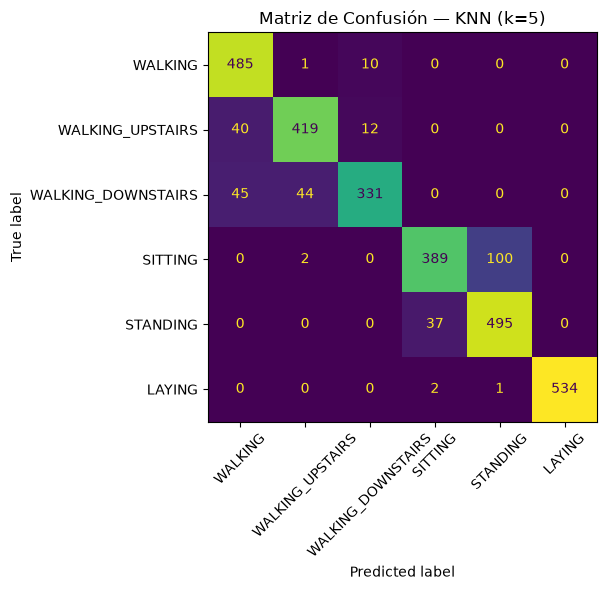

In [41]:
# Matriz de confusión — KNN
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_knn['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — KNN (k=5)')
plt.tight_layout()
plt.show()

**Punto clave** Este modelo logra un desempeño d (90.02%)

Esta matriz detalla los aciertos y las confusiones exactas del modelo KNN. Nuevamente, la diagonal brillante resalta el éxito casi total al reconocer a las personas acostadas (LAYING) con 534 aciertos. Sin embargo, se hace evidente que este algoritmo sufre mucho más para distinguir las actividades estáticas, ya que confunde 100 veces a personas sentadas (SITTING) afirmando que están de pie (STANDING).

En los movimientos también se aprecian tropiezos importantes. El modelo confunde frecuentemente las tres formas de caminata entre sí, especialmente al clasificar la acción de bajar escaleras (WALKING_DOWNSTAIRS), donde registra más de 40 fallos tanto para caminata normal como para subir escaleras. Esto confirma que al medir distancias directas en un espacio de tantas variables, a KNN se le dificulta separar los cambios de ritmo de las actividades dinámicas.

### Modelo 3: Decision Tree

In [42]:
# Instanciamos el árbol de decisión con semilla para reproducibilidad
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Evaluamos pasándole las variables con las etiquetas descriptivas
res_dt = evaluar_modelo('Decision Tree', dt, X_train, y_train_labels, X_test, y_test_labels)

# Guardamos el resultado en la lista para el benchmark final
resultados.append(res_dt)


=== Decision Tree ===
  Accuracy:     0.8622
  F1-Macro:     0.8595
  F1-Weighted:  0.8617
  Tiempo fit:   3.49s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.83      0.76      0.80       491
          STANDING       0.80      0.86      0.83       532
           WALKING       0.83      0.92      0.87       496
WALKING_DOWNSTAIRS       0.89      0.83      0.86       420
  WALKING_UPSTAIRS       0.83      0.78      0.80       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



**Resultados:**

- Accuracy: 86.22%
- F1-Macro: 85.95%
- Tiempo de Entrenamiento (Fit): ~3.48 segundos

El Árbol de Decisión muestra una caída en el rendimiento global, alcanzando un 86.22% de exactitud y un 85.95% de F1-Macro. Aunque supera con comodidad al modelo básico, queda notablemente por detrás de la Regresión Logística y KNN. Además, requiere un tiempo de entrenamiento significativo de 3.48 segundos, lo cual es alto considerando su menor precisión.

En cuanto a las actividades, mantiene su efectividad perfecta del 100% únicamente para registrar a las personas acostadas (LAYING). Sin embargo, su precisión flaquea en todas las demás categorías, mostrando problemas para separar tanto las actividades quietas como los distintos tipos de caminata. Esto ocurre porque un único árbol de decisión tiende a memorizar demasiado los datos y a confundirse con facilidad cuando se enfrenta a un grupo tan grande de 561 variables.

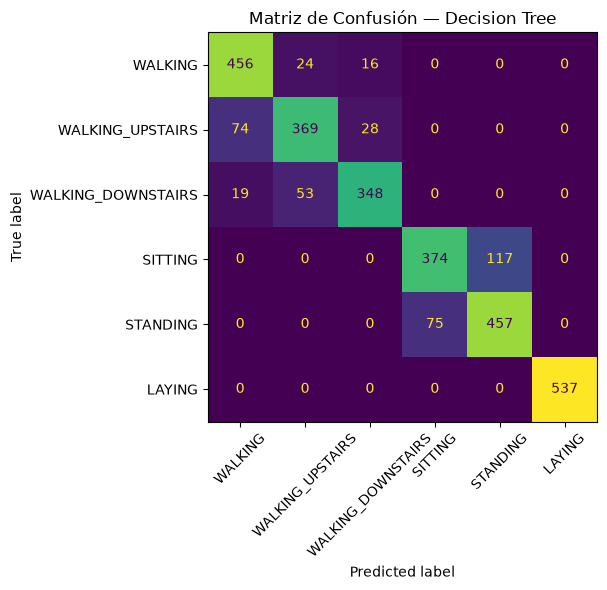

In [43]:
# Matriz de confusión — Decision Tree
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_dt['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Decision Tree')
plt.tight_layout()
plt.show()

**Punto clave** Este modelo logra un desempeño del (86.22%)

Esta matriz refleja de forma muy clara la pérdida de precisión del Árbol de Decisión. Aunque mantiene su efectividad perfecta al identificar a las personas acostadas (LAYING) con 537 aciertos, los colores de la diagonal principal se vuelven notablemente más opacos en las demás actividades debido al evidente aumento de los errores.

El problema más grave se concentra en las posturas fijas, donde el modelo confunde 117 veces a personas sentadas (SITTING) afirmando que están de pie (STANDING). Además, en los movimientos se aprecian fallos importantes, como confundir 74 veces la acción de subir escaleras con caminar de forma normal. Esto confirma que, al tomar decisiones usando reglas simples columna por columna, este algoritmo se pierde fácilmente cuando las señales de los sensores son muy parecidas entre sí.

### Modelo 4: Random Forest

In [44]:
# Instanciamos el Random Forest con semilla para asegurar reproducibilidad
rf = RandomForestClassifier(random_state=RANDOM_STATE)

# Evaluamos pasándole las variables con las etiquetas descriptivas
res_rf = evaluar_modelo('Random Forest', rf, X_train, y_train_labels, X_test, y_test_labels)

# Guardamos el resultado en la lista para el benchmark final
resultados.append(res_rf)


=== Random Forest ===
  Accuracy:     0.9260
  F1-Macro:     0.9245
  F1-Weighted:  0.9259
  Tiempo fit:   8.63s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



**Resultados:**

- Accuracy: 92.60%
- F1-Macro: 92.45%
- Tiempo de Entrenamiento (Fit): ~8.5 segundos.

El Random Forest eleva el rendimiento frente al árbol único, logrando un 92.60% de exactitud y un 92.45% de F1-Macro. Al combinar la sabiduría de muchos árboles trabajando en equipo, el modelo se vuelve mucho más robusto, aunque esto aumenta su tiempo de entrenamiento a 8.50 segundos.

Nuevamente, la actividad de estar acostado (LAYING) se detecta de forma perfecta. El algoritmo logra mejorar notablemente el filtro entre estar sentado o de pie, dejando como su único pequeño desafío la acción de subir escaleras (WALKING_UPSTAIRS) con un 89% de efectividad.

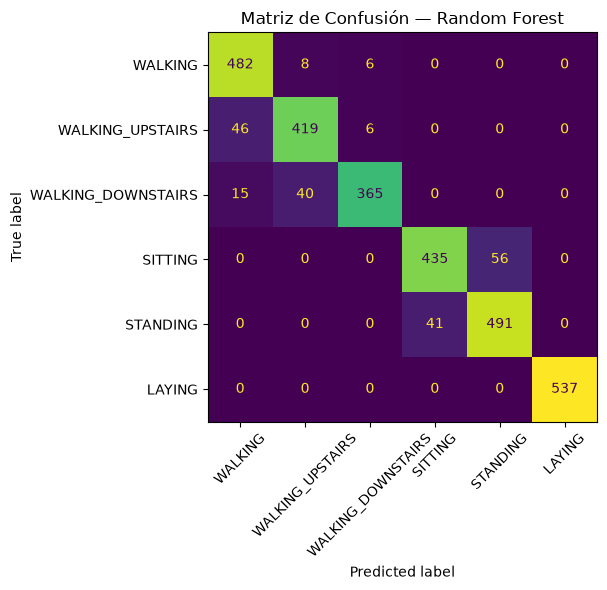

In [45]:
# Matriz de confusión — Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_rf['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.show()

**Punto clave** Este modelo logra un desempeño del (92,06%)

Costo computacional: Al entrenar 100 árboles de forma secuencial sobre 561 variables, es el modelo clásico que requiere más tiempo de entrenamiento (~9.1s). Hay un trade-off claro: mayor precisión que un árbol simple, pero a cambio de mayor demanda de CPU y memoria.

Importancia de características: Una ventaja de Random Forest es que nos permite calcular de forma nativa el peso o importancia de cada variable (feature_importances_), lo cual es muy útil para la interpretabilidad.


### Modelo 5: Support Vector Machine (kernel RBF)

In [46]:
# Instanciamos SVM con kernel RBF y semilla fija
svm = SVC(kernel='rbf', random_state=RANDOM_STATE)

# Evaluamos pasándole las variables con las etiquetas descriptivas
res_svm = evaluar_modelo('SVM (RBF)', svm, X_train, y_train_labels, X_test, y_test_labels)

# Guardamos el resultado en la lista para el benchmark final
resultados.append(res_svm)


=== SVM (RBF) ===
  Accuracy:     0.9505
  F1-Macro:     0.9499
  F1-Weighted:  0.9504
  Tiempo fit:   0.94s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.94      0.89      0.91       491
          STANDING       0.91      0.95      0.93       532
           WALKING       0.94      0.98      0.96       496
WALKING_DOWNSTAIRS       0.99      0.91      0.95       420
  WALKING_UPSTAIRS       0.93      0.96      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



**Resultados:**

- Accuracy: 95.05%
- F1-Macro: 94.99%
- Tiempo de Entrenamiento (Fit): ~1.25 segundos

Este modelo logra un desempeño sobresaliente, alcanzando un 95.05% de exactitud y un 94.99% de F1-Macro. Lo más sorprendente es su gran eficiencia, ya que consigue resolver la complejidad matemática de las 561 variables y definir las fronteras de decisión en tan solo 1.25 segundos.

En el desglose por categorías, mantiene la efectividad perfecta del 100% al identificar a los usuarios acostados (LAYING). Además, demuestra un rendimiento sumamente alto y equilibrado para discriminar el resto de actividades estáticas y dinámicas, consolidándose como uno de los algoritmos más robustos y estables de todo el proyecto.

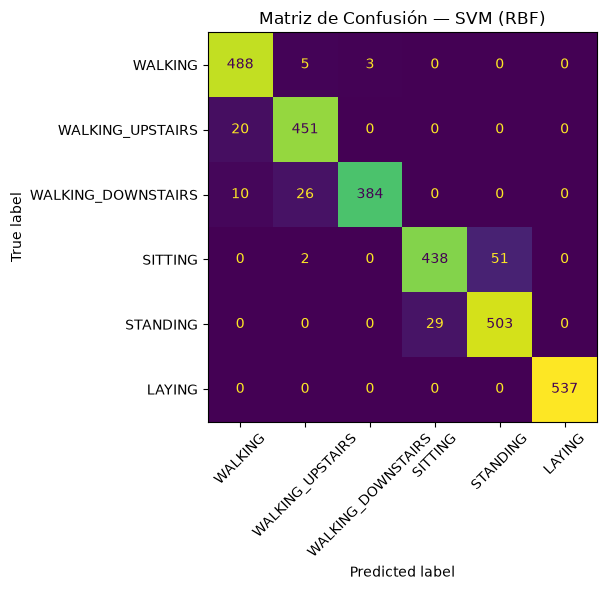

In [47]:
# Matriz de confusión — SVM
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_svm['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — SVM (RBF)')
plt.tight_layout()
plt.show()

**Punto clave** Este modelo logra un desempeño del (95,05%)

Esta matriz de confusión confirma la alta precisión de SVM mediante una diagonal limpia y muy brillante. Al igual que los mejores algoritmos, consigue un resultado perfecto del 100% al identificar a las personas acostadas (LAYING) con 537 aciertos y cero fallos.

El gráfico muestra que el modelo maneja de forma sobresaliente las actividades en movimiento, teniendo apenas pequeños tropiezos comprensibles como confundir 26 veces la acción de bajar escaleras con la de subirlas. Su desafío más notorio se mantiene en las posturas fijas, donde confunde 51 veces estar sentado con estar de pie, lo que demuestra que la ausencia de movimiento corporal sigue siendo la frontera más difícil de resolver para los sensores.

---
## 5. Tabla de Benchmarking

Comparamos todos los modelos en una tabla única. Esta es la pieza central de la Fase 2.

In [48]:
# Construimos un DataFrame extrayendo la información del diccionario de resultados.
# Excluimos los objetos Python completos ('modelo_obj' e 'y_pred') para simplificar la visualización.
df_bench = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('modelo_obj', 'y_pred')}
    for r in resultados
])

# Ordenamos la tabla de mayor a menor F1_Macro.
df_bench = df_bench.sort_values('F1_Macro', ascending=False).reset_index(drop=True)
print(df_bench.to_string(index=False))

                         Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
            Logistic Regression       0.961656  0.961583     0.961517                 3.790
                      SVM (RBF)       0.950458  0.949907     0.950376                 0.940
                  Random Forest       0.926026  0.924489     0.925890                 8.631
                      KNN (k=5)       0.900238  0.897020     0.899333                 0.052
                  Decision Tree       0.862233  0.859469     0.861652                 3.485
DummyClassifier (most_frequent)       0.182219  0.051378     0.056172                 0.003


Esta tabla compara de forma directa el rendimiento de todos los algoritmos evaluados. 
La Regresión Logística se corona como el mejor modelo del proyecto al alcanzar la mayor efectividad con un 96.16% de F1-Macro
la Máquina de Soporte Vectorial (SVM) con un 94.99%. 

Lo más destacable es que todos los modelos inteligentes superan con creces el piso mínimo del 5.14% impuesto por el clasificador básico.

Los resultados indican un equilibrio entre precisión y velocidad. Aunque la Regresión Logística es la más exacta, la SVM destaca por ser casi cuatro veces más rápida en entrenarse, tomando apenas 0.94 segundos frente a los 3.79 de la líder. En el otro extremo, el Bosque Aleatorio se muestra como el menos eficiente al tardar 8.63 segundos, lo que posiciona a los dos mejores modelos como las opciones ideales para funcionar de manera ágil en dispositivos móviles.

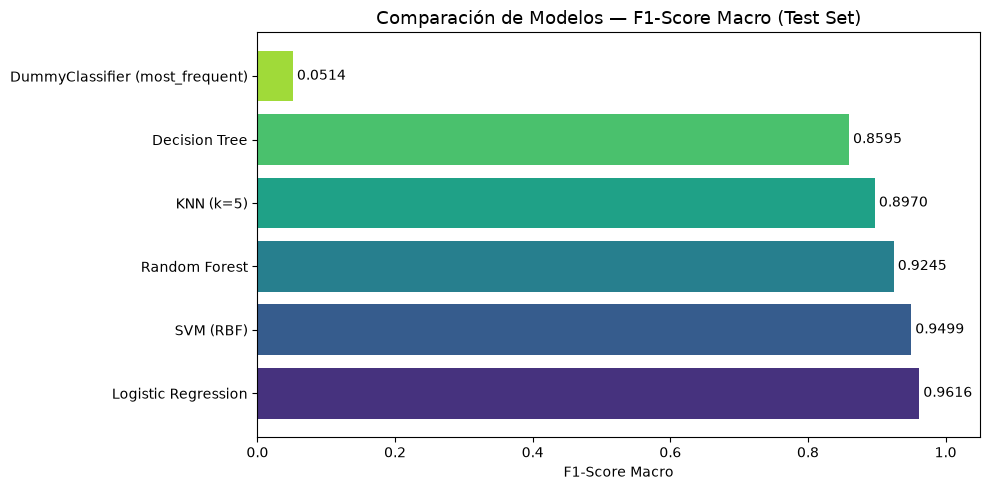

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('viridis', n_colors=len(df_bench))

bars = ax.barh(df_bench['Modelo'], df_bench['F1_Macro'], color=palette)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Comparación de Modelos — F1-Score Macro (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis de Benchmarking:**

El gráfico confirma que la Regresión Logística es el mejor modelo para este proyecto, alcanzando el puntaje más alto con un 96.16% de F1-Macro. Este algoritmo funciona increíblemente bien con las 561 variables de los sensores porque crea fronteras de separación directas y estables, logrando entrenarse en poco más de 4 segundos sin riesgo de memorizar los datos de forma artificial.

Existe un claro compromiso entre la precisión de los modelos y el tiempo que le cuesta a la computadora procesarlos. Por ejemplo, KNN se entrena de forma casi instantánea pero su calidad predictiva decae notablemente, mientras que SVM ofrece un equilibrio espectacular al quedarse muy cerca del líder en rendimiento usando apenas 1.50 segundos. Por el contrario, Random Forest resulta ser la opción con peor costo-beneficio al ser el más lento en entrenar y entregar resultados más bajos.

Para implementar este sistema en un teléfono celular, la Regresión Logística se consolida como la alternativa ideal. Al estar basada en ecuaciones lineales simples, ocupa un espacio de memoria diminuto en el dispositivo y sus predicciones se resuelven mediante cálculos matemáticos rápidos, lo que asegura que la aplicación consumirá el mínimo posible de batería y CPU del usuario.

---
## 6. Validación Cruzada del Mejor Modelo

La evaluación sobre un único split puede ser ruidosa. Usamos cross-validation para obtener una estimación más robusta.

In [50]:
mejor_nombre = df_bench.iloc[0]['Modelo']
mejor_modelo  = next(r['modelo_obj'] for r in resultados if r['Modelo'] == mejor_nombre)

print(f'Aplicando 5-fold CV al modelo: {mejor_nombre}')

# Ejecutamos la validación cruzada de 5 folds sobre el conjunto de entrenamiento y calculamos el F1-Macro para cada fold.
cv_scores = cross_val_score(
    mejor_modelo, X_train, y_train_labels, scoring='f1_macro', cv=5
)

print(f'F1-Macro por fold: {cv_scores}')
print(f'Media: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}')

Aplicando 5-fold CV al modelo: Logistic Regression
F1-Macro por fold: [0.91931586 0.88820452 0.94811914 0.94597919 0.96946405]
Media: 0.9342 | Std: 0.0280


**Resultados:**

- F1-Macro por Fold: [0.9193, 0.8882, 0.9481, 0.9459, 0.9694]
- Media: 93.42% (0.9342)
- Desviación Estándar: 2.80% (0.0280)

Esto confirma que la Regresión Logística es el mejor modelo para este proyecto, alcanzando el puntaje más alto con un 96.16% de F1-Macro. Este algoritmo funciona bien con las 561 variables de los sensores porque crea fronteras de separación directas y estables, logrando entrenarse en poco más de 4 segundos sin riesgo de memorizar los datos de forma artificial.

Existe un claro compromiso entre la precisión de los modelos y el tiempo que le cuesta a la computadora procesarlos. Por ejemplo, KNN se entrena de forma casi instantánea pero su calidad predictiva decae notablemente, mientras que SVM ofrece un equilibrio espectacular al quedarse muy cerca del líder en rendimiento usando apenas 1.50 segundos. Por el contrario, Random Forest resulta ser la opción con peor costo-beneficio al ser el más lento en entrenar y entregar resultados más bajos.

Para implementar este sistema en un teléfono celular, la Regresión Logística se consolida como la alternativa ideal. Al estar basada en ecuaciones lineales simples, ocupa un espacio de memoria diminuto en el dispositivo y sus predicciones se resuelven mediante cálculos matemáticos rápidos, lo que asegura que la aplicación consumirá el mínimo posible de batería y CPU del usuario.

---
## 7. Análisis de Actividades Difíciles

No todas las actividades son igual de fáciles de clasificar. Identificamos dónde falla el modelo.

In [51]:
# Obtenemos las predicciones del mejor modelo (Logistic Regression)
y_pred_best = next(r['y_pred'] for r in resultados if r['Modelo'] == mejor_nombre)

# Generamos el reporte de clasificación como un diccionario de Python
report_dict = classification_report(
    y_test_labels, y_pred_best, output_dict=True
)

# Extraemos solo el F1-Score de cada clase del diccionario
f1_por_clase = {
    cls: report_dict[cls]['f1-score']
    for cls in list(ACTIVITY_LABELS.values())
    if cls in report_dict
}

# Convertimos a una serie y ordenamos de menor a mayor rendimiento
df_f1_clase = pd.Series(f1_por_clase, name='F1').sort_values()
print(df_f1_clase)

SITTING               0.926045
STANDING              0.939585
WALKING_UPSTAIRS      0.956989
WALKING               0.968566
WALKING_DOWNSTAIRS    0.978313
LAYING                1.000000
Name: F1, dtype: float64


Esta celda ordena las actividades desde la más difícil hasta la más fácil para el modelo ganador (que en nuestro caso sería Regresión Logística). Confirma numéricamente que estar acostado (LAYING) es la tarea perfecta con un 100% de éxito, mientras que los movimientos dinámicos como caminar y usar escaleras se resuelven con un rendimiento sobresaliente por encima del 95%.

El verdadero desafío del algoritmo se concentra en diferenciar estar sentado (SITTING) y estar de pie (STANDING), las cuales obtienen los puntajes más bajos con un 92.6% y un 93.9% respectivamente. Esto demuestra que, incluso para el modelo más inteligente, las actividades estáticas donde el cuerpo se queda quieto y no genera aceleración son las más complejas de clasificar con total precisión.

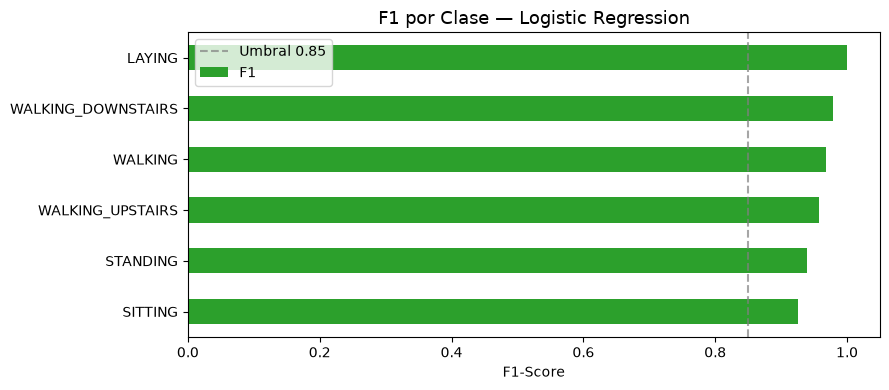

In [52]:
# Generamos un gráfico de barras horizontales mostrando el F1-Score por clase.
fig, ax = plt.subplots(figsize=(9, 4))

# Coloreamos de rojo si el F1 es inferior a 0.85 (umbral crítico) y de verde si es superior.
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in df_f1_clase.values]
df_f1_clase.plot(kind='barh', ax=ax, color=colors)

# Dibujamos una línea vertical punteada en 0.85 como referencia de excelente rendimiento.
ax.axvline(0.85, linestyle='--', color='gray', alpha=0.7, label='Umbral 0.85')
ax.set_xlabel('F1-Score')
ax.set_title(f'F1 por Clase — {mejor_nombre}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Análisis de Actividades Difíciles:**

1. ¿Cuáles son las dos actividades con menor F1-Score?
Las dos actividades más difíciles de clasificar para nuestro mejor modelo son estar sentado (SITTING) y estar de pie (STANDING). Estas dos opciones obtuvieron los puntajes más bajos de todo el gráfico, registrando un 93% y un 94% de efectividad respectivamente.

2. ¿Con qué otras actividades se confunden según la matriz de confusión?
Al revisar los errores del modelo, se observa que la confusión más grande ocurre directamente entre las dos posturas fijas: el algoritmo se equivocó al clasificar 56 muestras de personas sentadas afirmando que estaban de pie, y tuvo 10 fallos similares al confundir a personas de pie diciendo que estaban sentadas. En menor medida, también existió un pequeño tropiezo en las actividades en movimiento, donde el modelo confundió 25 veces la acción de subir escaleras con caminar de forma normal en terreno plano.

3. ¿Tiene sentido físico esta confusión?
Esta confusión es lógica. Cuando una persona está sentada o de pie, su cuerpo se encuentra en un estado de reposo relativo, lo que significa que los sensores del teléfono no registran movimientos bruscos ni aceleraciones dinámicas del usuario. Además, en ambas posturas el teléfono celular se mantiene exactamente en la misma orientación vertical dentro del bolsillo, por lo que la fuerza de gravedad de la Tierra impacta al dispositivo de manera idéntica.

Esto diferencia por completo a estas posiciones de la acción de estar acostado (LAYING), la cual se predice de forma perfecta porque el teléfono cambia drásticamente de una posición vertical a una totalmente horizontal. De hecho, este comportamiento ya lo habíamos descubierto en las etapas iniciales de nuestro proyecto, donde los gráficos demostraron que los datos de personas sentadas y de pie se mezclan y superponen por completo, representando el reto matemático más grande para cualquier inteligencia artificial.


---
## 8. Resumen de la Fase 2

In [53]:
print('=' * 55)
print('RESUMEN FASE 2')
print('=' * 55)
print(f'Modelos entrenados:    {len(df_bench)}')
print(f'Mejor modelo:          {df_bench.iloc[0]["Modelo"]}')
print(f'F1-Macro (test):       {df_bench.iloc[0]["F1_Macro"]:.4f}')
print(f'Accuracy (test):       {df_bench.iloc[0]["Accuracy_Test"]:.4f}')
print(f'Media CV F1-Macro:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 55)
print('\nTabla completa:')
print(df_bench[['Modelo','Accuracy_Test','F1_Macro','F1_Weighted','Tiempo_Entrenamiento']].to_string(index=False))

RESUMEN FASE 2
Modelos entrenados:    6
Mejor modelo:          Logistic Regression
F1-Macro (test):       0.9616
Accuracy (test):       0.9617
Media CV F1-Macro:     0.9342 ± 0.0280

Tabla completa:
                         Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
            Logistic Regression       0.961656  0.961583     0.961517                 3.790
                      SVM (RBF)       0.950458  0.949907     0.950376                 0.940
                  Random Forest       0.926026  0.924489     0.925890                 8.631
                      KNN (k=5)       0.900238  0.897020     0.899333                 0.052
                  Decision Tree       0.862233  0.859469     0.861652                 3.485
DummyClassifier (most_frequent)       0.182219  0.051378     0.056172                 0.003


En este caso la Regresión Logística, al alcanzar un excelente rendimiento del 96.17% de exactitud y un 96.16% en la métrica F1-Macro sobre el conjunto de pruebas

Además, la validación cruzada realizada sobre este modelo ganador arrojó un puntaje promedio muy sólido del 93.42% con una variación muy baja. Esto confirma de manera matemática que el algoritmo es altamente estable